### Import Libraries

In [90]:
import numpy as np 
import pandas as pd  

import matplotlib.pyplot as plt 
import seaborn as sns 

# Display all columns (useful for EDA)
pd.set_option("display.max_columns", None)

In [91]:
## Load the Dataset

df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [92]:
df.shape

(10000, 14)

In [93]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [95]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [96]:
## Check missing value
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [97]:
## Check duplicate values
df.duplicated().sum()

np.int64(0)

In [98]:
# Check target variable Distributon

df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

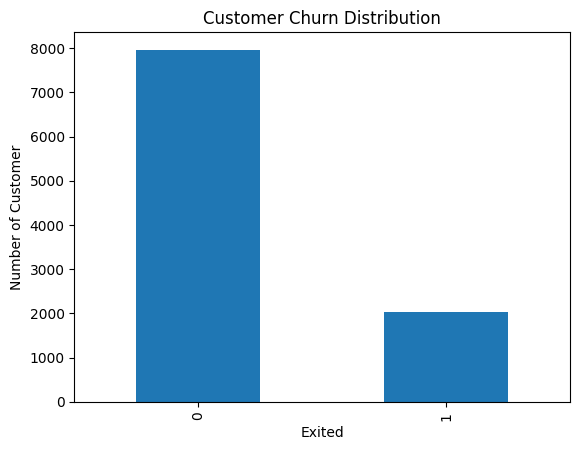

In [99]:
## visualize
df["Exited"].value_counts().plot(kind = "bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Exited")
plt.ylabel("Number of Customer")
plt.show()


In [100]:
## View Categorical Features
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [101]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [102]:
## Correlation(Numerical Features)
corr = df.corr(numeric_only=True)

corr["Exited"].sort_values(ascending = False)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
CustomerId        -0.006248
HasCrCard         -0.007138
Tenure            -0.014001
RowNumber         -0.016571
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64

### Data Preprocessing

In [103]:
## Remove unnecessary columns
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

df.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [104]:
## Seperate features and target

X = df.drop("Exited", axis=1)
y = df["Exited"]

### Encode Categorical Variables

In [105]:
X.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [106]:
from sklearn.preprocessing import LabelEncoder

In [107]:
le = LabelEncoder()


# Encode Gender
X["Gender"] = le.fit_transform(X["Gender"])

In [108]:
# Enocde Geography

X = pd.get_dummies(X, columns=["Geography"], drop_first=True)

In [109]:
X.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


### Train-Test Split

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [112]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000,)
(2000,)


In [113]:
X = X.astype(int)

### Convert NumPy Arrays to PyTorch Tensors

In [114]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

### Create ANN module

In [115]:
import torch.nn as nn 

class CustomerChurnANN(nn.Module):

    def __init__(self):
        super(CustomerChurnANN, self).__init__()
        
        self.network = nn.Sequential(

            nn.Linear(11,16),
            nn.ReLU(),

            nn.Linear(16,8),
            nn.ReLU(),

            nn.Linear(8,1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.network(x)

        return x

### Create the Model

In [116]:
model = CustomerChurnANN()

print(model)

CustomerChurnANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [117]:
## Loss Function 
criterion = nn.BCELoss()

In [118]:
## Optimizer 
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr = 0.001)

### Training Loop

In [119]:
epochs = 100

for epoch in range(epochs):

    # Training mode
    model.train()

    # forward pass
    outputs = model(X_train)

    # Calculate loss 
    loss = criterion(outputs, y_train)

    # clear previous gredient
    optimizer.zero_grad()

    # Backwardpropagartion
    loss.backward()

    # update weights
    optimizer.step()

    if(epoch+1)%10 == 0:
        print(f"epoch [{epoch+1}/{epochs}], Loss:{loss.item():.4f}")



epoch [10/100], Loss:0.7830
epoch [20/100], Loss:0.7652
epoch [30/100], Loss:0.7471
epoch [40/100], Loss:0.7273
epoch [50/100], Loss:0.7052
epoch [60/100], Loss:0.6805
epoch [70/100], Loss:0.6534
epoch [80/100], Loss:0.6239
epoch [90/100], Loss:0.5933
epoch [100/100], Loss:0.5637


### Evaluate the Model

In [120]:
model.eval()

with torch.no_grad():
    y_pred = model(X_test)

predictions = (y_pred >= 0.5).float()

### Calculate Accuracy

In [121]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test.numpy(),
    predictions.numpy()
)

print(f"Accuracy:{accuracy:.4f}")


Accuracy:0.8045


### DataLoader

In [122]:
from torch.utils.data import DataLoader, TensorDataset

### Create Dataset

In [123]:
train_dataset = TensorDataset(X_train, y_train)

test_dataset = TensorDataset(X_test, y_test)

### Create DataLoader

In [124]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size =32, shuffle= False)

### Updated Training Loop

In [125]:
epochs = 100

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    for inputs, labels in train_loader :

        # Forward pass
        outputs = model(inputs)

        # calculate loss
        loss = criterion(outputs, labels)

        # clear gradient
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # update weights
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 10/100, Loss: 0.3404
Epoch 20/100, Loss: 0.3325
Epoch 30/100, Loss: 0.3281
Epoch 40/100, Loss: 0.3256
Epoch 50/100, Loss: 0.3229
Epoch 60/100, Loss: 0.3214
Epoch 70/100, Loss: 0.3198
Epoch 80/100, Loss: 0.3192
Epoch 90/100, Loss: 0.3184
Epoch 100/100, Loss: 0.3174


### Evaluate with DataLoader

In [126]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        predicted = (outputs >= 0.5).float()

        all_predictions.extend(predicted.numpy())

        all_labels.extend(labels.numpy())

In [127]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8585


Split Training Data into Train and Validation Sets


In [128]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [129]:
# Create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_split, y_train_split)
val_dataset = TensorDataset(X_val, y_val)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False)

In [130]:
# Create an Accuracy Function
def calculate_accuracy(outputs, labels):

    predictions = (outputs >= 0.5).float()

    correct = (predictions == labels).sum()

    accuracy = correct / labels.shape[0]

    return accuracy.item()

In [131]:
# Complete Training Loop
train_losses = []
val_losses = []

train_acc = []
val_acc = []

best_val_loss = float("inf")

patience = 10
counter = 0

epochs = 100

for epoch in range(epochs):

    # ---------- Training ----------
    model.train()

    running_loss = 0
    running_acc = 0

    for inputs, labels in train_loader:

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs, labels)

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = running_acc / len(train_loader)

    train_losses.append(epoch_train_loss)
    train_acc.append(epoch_train_acc)

    # ---------- Validation ----------
    model.eval()

    running_val_loss = 0
    running_val_acc = 0

    with torch.no_grad():

        for inputs, labels in val_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            running_val_acc += calculate_accuracy(outputs, labels)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = running_val_acc / len(val_loader)

    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

    # ---------- Save Best Model ----------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss

        torch.save(model.state_dict(), "best_model.pth")

        counter = 0

    else:

        counter += 1

        if counter >= patience:

            print("Early Stopping Triggered!")

            break

Epoch 1/100 | Train Loss: 0.3212 | Val Loss: 0.3016 | Train Acc: 0.8675 | Val Acc: 0.8675
Epoch 2/100 | Train Loss: 0.3206 | Val Loss: 0.3040 | Train Acc: 0.8678 | Val Acc: 0.8681
Epoch 3/100 | Train Loss: 0.3197 | Val Loss: 0.3058 | Train Acc: 0.8678 | Val Acc: 0.8650
Epoch 4/100 | Train Loss: 0.3195 | Val Loss: 0.3084 | Train Acc: 0.8692 | Val Acc: 0.8650
Epoch 5/100 | Train Loss: 0.3196 | Val Loss: 0.3076 | Train Acc: 0.8678 | Val Acc: 0.8631
Epoch 6/100 | Train Loss: 0.3195 | Val Loss: 0.3085 | Train Acc: 0.8661 | Val Acc: 0.8638
Epoch 7/100 | Train Loss: 0.3190 | Val Loss: 0.3090 | Train Acc: 0.8684 | Val Acc: 0.8631
Epoch 8/100 | Train Loss: 0.3188 | Val Loss: 0.3106 | Train Acc: 0.8678 | Val Acc: 0.8638
Epoch 9/100 | Train Loss: 0.3193 | Val Loss: 0.3093 | Train Acc: 0.8672 | Val Acc: 0.8650
Epoch 10/100 | Train Loss: 0.3190 | Val Loss: 0.3087 | Train Acc: 0.8681 | Val Acc: 0.8650
Epoch 11/100 | Train Loss: 0.3187 | Val Loss: 0.3094 | Train Acc: 0.8684 | Val Acc: 0.8644
Early St

### Load the Best Model

In [132]:

model.load_state_dict(torch.load("best_model.pth"))

model.eval()

CustomerChurnANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Plot Training vs Validation Loss

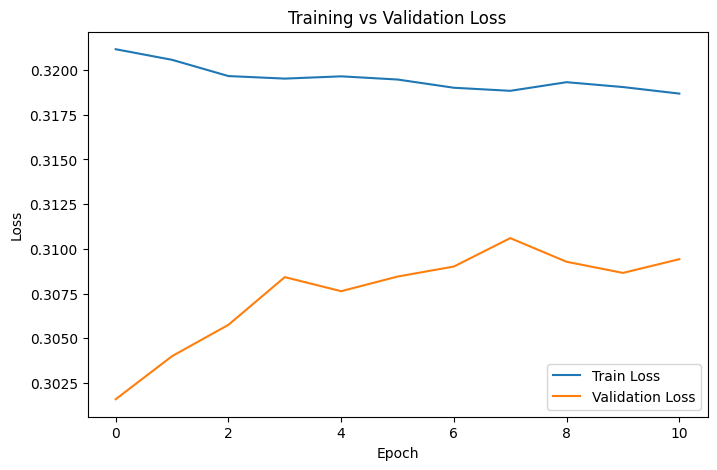

In [133]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [134]:
model.eval()

all_predictions = []
all_probabilities = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        probabilities = outputs

        predictions = (outputs >= 0.5).float()

        all_predictions.extend(predictions.numpy().flatten())
        all_probabilities.extend(probabilities.numpy().flatten())
        all_labels.extend(labels.numpy().flatten())

In [135]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8600


In [136]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

print(cm)

[[1523   84]
 [ 196  197]]


### Classification Report

In [137]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_predictions))

              precision    recall  f1-score   support

         0.0       0.89      0.95      0.92      1607
         1.0       0.70      0.50      0.58       393

    accuracy                           0.86      2000
   macro avg       0.79      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [138]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_labels, all_probabilities)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8541


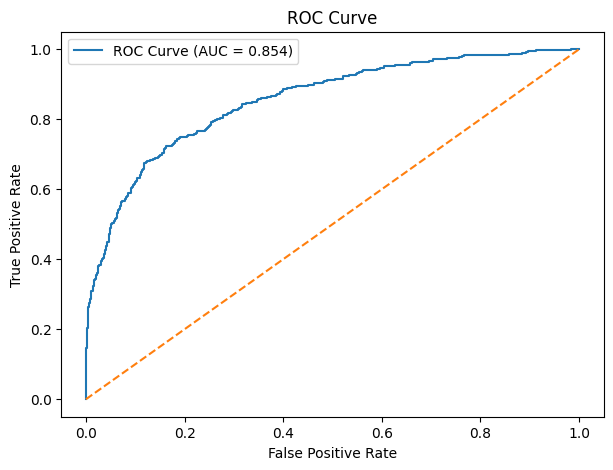

In [139]:
# Plot the ROC Curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_labels, all_probabilities)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### save the model

In [165]:
model.load_state_dict(
    torch.load("../models/customer_churn_ann.pth", map_location="cpu")
)

<All keys matched successfully>

In [166]:
import joblib

scaler = joblib.load("../models/scaler.pkl")

In [155]:
import torch

torch.save(model.state_dict(), "customer_churn_ann.pth")
print("Model saved successfully!")

Model saved successfully!


In [141]:
model = CustomerChurnANN()
model.load_state_dict(torch.load("customer_churn_ann.pth"))
model.eval()

CustomerChurnANN(
  (network): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

### Save the Scaler

In [142]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [163]:
import os

print(os.getcwd())

c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\Deep Learning\Customer churn prediction using ANN\notebooks


In [164]:
import os

print(os.path.exists("models/customer_churn_ann.pth"))

False


In [167]:
import os

os.chdir("..")
print(os.getcwd())

c:\Users\DIPANSHU SHUKLA\OneDrive\Desktop\Deep Learning\Customer churn prediction using ANN


In [168]:
torch.load("models/customer_churn_ann.pth")
joblib.load("models/scaler.pkl")

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
